# AERPAW Use Case Demonstration
* This Demonstration showcases the AERPAWEnvironment's specialized funcitonality for use with the AERPAW digial twin
* Includes initialization, visualization, and SNR calculation

## This Environment Provides
* A quick and minimial initialization of the simulation environment
* Straighforward ray-tracing computation of SNR values between all transmitters and receivers in the environment
* All the existing functionality of the general environment

## What's Next
* Incorporating Blender scripting to automatically fetch topology, building, and natural environment data from OpenStreetMaps and OpenTopography for a provided region
* Integrating this functionality directly into the AERPAW environment, to provide an accurate ray-tracing SNR model

2025-09-10 11:11:06.485164: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-10 11:11:06.495610: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757517066.508081   41610 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757517066.511557   41610 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757517066.520866   41610 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

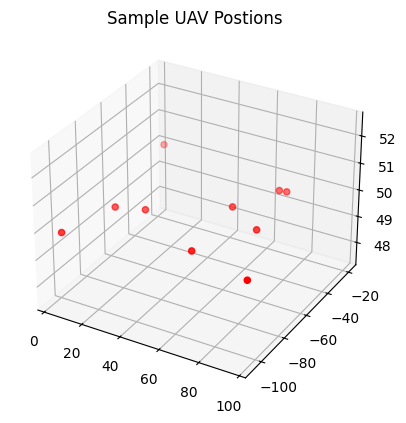

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from AERPAWEnvironment import AERPAWEnv

# Defining the scene, including receivers and transmitters

# Defining a generic UAV for simplicity
generic_uav = {
    "device_type": "tx",
    "mass": 5,
    "efficiency": 0.7,
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([1, 0, 0]),
    "bandwidth": 50,
    "rotor_area": 0.25,
    "signal_power": 3,
    "throughput_capacity": 625000000,
    "battery_capacity": 10000
}

# Configuring some generic uavs with random x and y positions
num_uavs = 10
uavs = []
for i in range(num_uavs):
    uav = dict(generic_uav)
    uav["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 50])
    uavs.append(uav)

# Plotting the positions in 3d
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
plt.title("Sample UAV Postions")
plt.show()

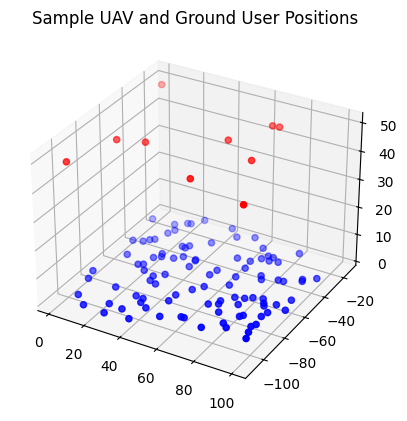

In [2]:
# Defining Generic Ground User

generic_gu = {
    "device_type": "rx",
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([0, 1, 0]),
    "bandwidth": 50,
    "desired_throughput": 375000
}

# Configuring some sample Ground Users
num_gus = 100
gus = []
for i in range(num_gus):
    gu = dict(generic_gu)
    gu["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 2])
    gus.append(gu)

# Plotting UAV and Ground User Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
plt.title("Sample UAV and Ground User Positions")
plt.show()

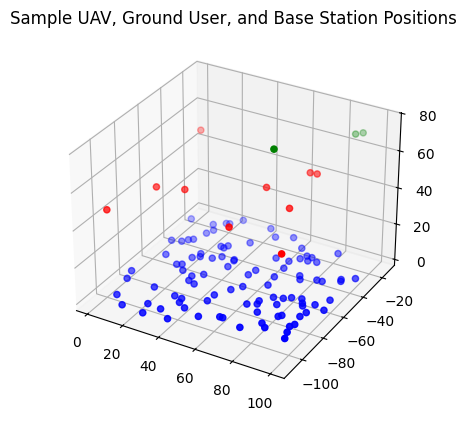

In [3]:
# Generating Sample Base Stations

# Defining a generic base station, then randomizing positions
generic_base_station = {
    "device_type": "rx",
    "position": np.zeros(3),
    "color": np.array([0, 0, 1]),
    "bandwidth": 50,
    "signal_power": 10,
    "throughput_capacity": 625000000,
    "battery_capacity": 1000000
}

# Adding some base stations with random positions
num_bs = 3
bss = []
for i in range(num_bs):
    bs = dict(generic_base_station)
    bs["position"] = np.array([np.random.rand() * 100, np.random.rand() * 100 - 110, 75])
    bss.append(bs)

# Plotting UAV, Ground User, and Base Station Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
axis.scatter([bss[i]["position"][0] for i in range(num_bs)],
           [bss[i]["position"][1] for i in range(num_bs)],
           [bss[i]["position"][2] for i in range(num_bs)],
           color="green")
plt.title("Sample UAV, Ground User, and Base Station Positions")
plt.show()

In [4]:
# Creating the scene with the sample devices
env = AERPAWEnv(scene_path='../data/RaleighUnionSquareStandardReference/raleigh_union_square.xml',
                uavs=uavs, ground_users=gus, base_stations=bss, temperature=300)
env.visualize()

In [5]:
# Computing SNR values between the transmitters and receivers in the scene
print(len(env.getSignalPowers()))

10


In [7]:
snr_dict = env.getSNR(max_depth=2, num_samples=100000, sampling_frequency=1.0, )  # Using default arguments, should be alright
print(f"Number of Recievers: {len(snr_dict)}")
print(f"Number of Transmitters: {len(snr_dict["gu0"])}")

Number of Recievers: 103
Number of Transmitters: 10
